In [1]:
import seaborn as sns
import matplotlib.pyplot as plt


In [9]:
# Load the Dow Jones dataset
df = sns.load_dataset("dowjones")
df

,Date,Price
0,1914-12-01,55.00
1,1915-01-01,56.55
2,1915-02-01,56.00
3,1915-03-01,58.30
4,1915-04-01,66.45
...,...,...
644,1968-08-01,883.72
645,1968-09-01,922.80
646,1968-10-01,955.47
647,1968-11-01,964.12


In [10]:
df.loc[20:50]

,Date,Price
20,1916-08-01,91.00
21,1916-09-01,97.45
22,1916-10-01,102.10
23,1916-11-01,107.90
24,1916-12-01,98.50
25,1917-01-01,97.15
26,1917-02-01,90.95
27,1917-03-01,94.65
28,1917-04-01,93.90
29,1917-05-01,93.35


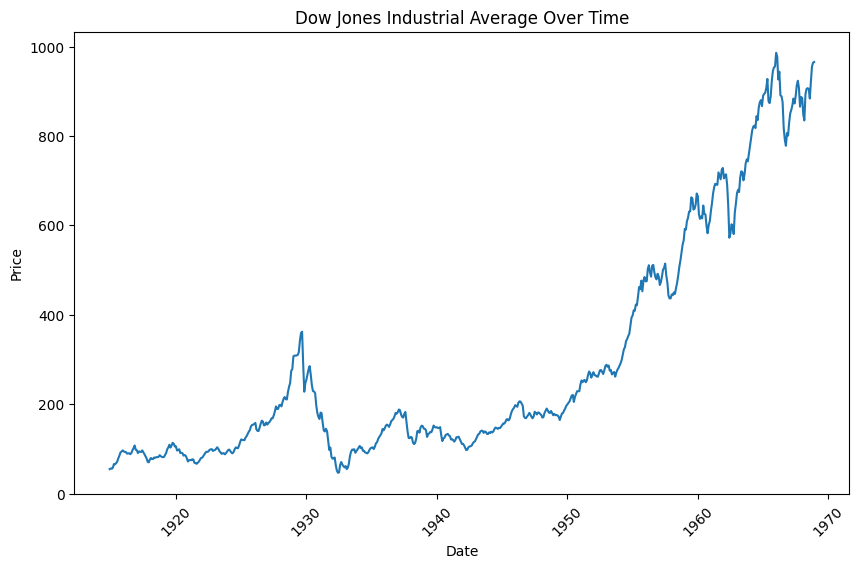

In [3]:
# Plotting the time series

plt.figure(figsize=(10,6))
sns.lineplot(data=df,
             x="Date", 
             y="Price")
plt.title("Dow Jones Industrial Average Over Time")
plt.xticks(rotation=45)
plt.show()

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Check data shape and column data types
print("--- Info ---")
print(df.info())

# 2. Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 3. Statistical summary
print("\n--- Summary Statistics ---")
print(df['Price'].describe())

# 4. Critical Step: Convert Date string to datetime object
df["Date"] = pd.to_datetime(df["Date"])


--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                649 non-null    datetime64[ns]
 1   Price               649 non-null    float64       
 2   Rolling_Volatility  638 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 15.3 KB
None

--- Missing Values ---
Date                   0
Price                  0
Rolling_Volatility    11
dtype: int64

--- Summary Statistics ---
count    649.000000
mean     290.807319
std      256.062906
min       46.850000
25%      106.900000
50%      172.270000
75%      436.730000
max      985.930000
Name: Price, dtype: float64


In [6]:
# Set default style for scannable graphs
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 10))


<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

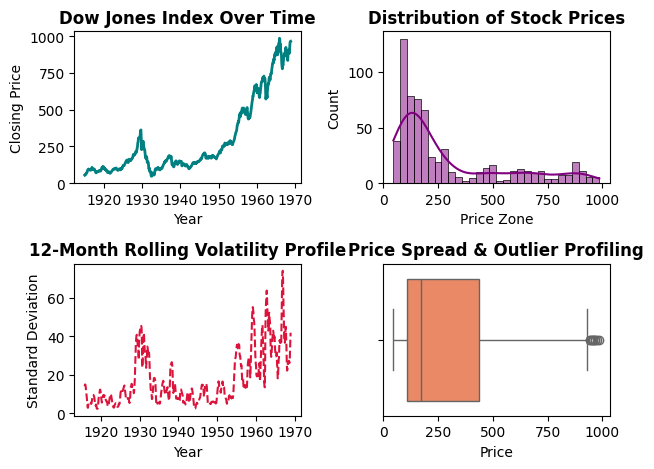

In [7]:
plt.subplot(2, 2, 1)
sns.lineplot(data=df, x="Date", y="Price", color="teal", linewidth=2)
plt.title("Dow Jones Index Over Time", fontsize=12, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Closing Price")


plt.subplot(2, 2, 2)
sns.histplot(data=df, x="Price", kde=True, color="purple", bins=30)
plt.title("Distribution of Stock Prices", fontsize=12, fontweight="bold")
plt.xlabel("Price Zone")

plt.subplot(2, 2, 3)
df["Rolling_Volatility"] = df["Price"].rolling(window=12).std()
sns.lineplot(
    data=df, x="Date", y="Rolling_Volatility", color="crimson", linestyle="--"
)
plt.title("12-Month Rolling Volatility Profile", fontsize=12, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Standard Deviation")


plt.subplot(2, 2, 4)
sns.boxplot(data=df, x="Price", color="coral")
plt.title("Price Spread & Outlier Profiling", fontsize=12, fontweight="bold")



plt.tight_layout()
plt.show()


In [17]:
# Lets look at few middle values to understand Rolling_Volatility
df[20:50]

,Date,Price,Rolling_Volatility
20,1916-08-01,91.00,3.123333
21,1916-09-01,97.45,2.849761
22,1916-10-01,102.10,3.921510
23,1916-11-01,107.90,5.716656
24,1916-12-01,98.50,5.788265
25,1917-01-01,97.15,5.827812
26,1917-02-01,90.95,5.933819
27,1917-03-01,94.65,5.915997
28,1917-04-01,93.90,5.705664
29,1917-05-01,93.35,5.517965


C:\Users\UCT\AppData\Local\Temp\ipykernel_23420\1785239034.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly_avg.tail(15),


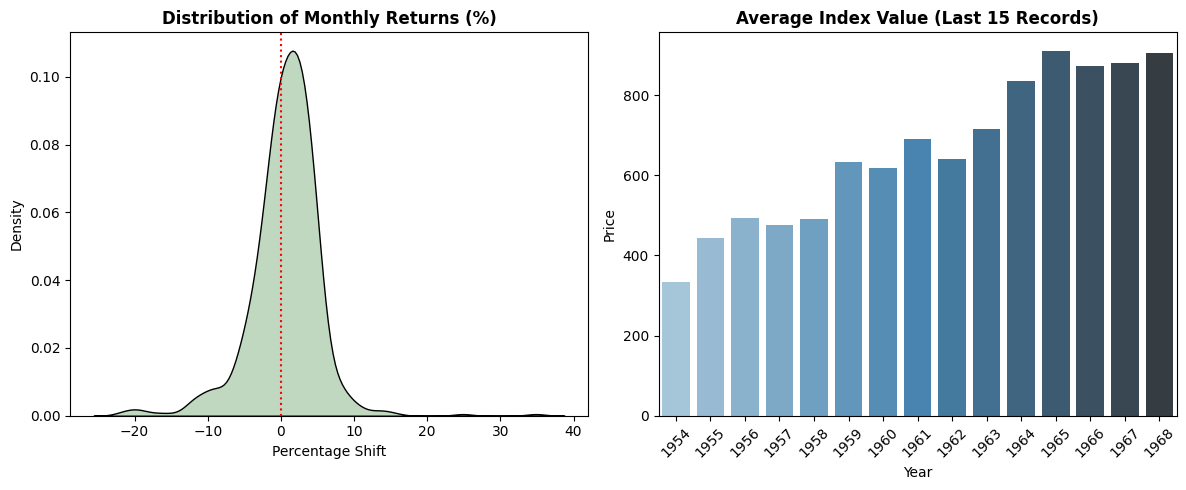

In [12]:
# Create engineered metrics

plt.figure(figsize=(12, 5))

# Plot performance returns distribution
plt.subplot(1, 2, 1)

# calculate the percentage change in price between consecutive rows
df["Monthly_Return"] = df["Price"].pct_change() * 100

sns.kdeplot( data=df, 
            x="Monthly_Return",
            fill=True, color="darkgreen", edgecolor="black"
)
plt.axvline(0, color="red", linestyle=":")
plt.title("Distribution of Monthly Returns (%)", fontweight="bold")
plt.xlabel("Percentage Shift")

# Plot macro progression line
plt.subplot(1, 2, 2)

# Aggregating average prices by decade/year block
df["Year"] = df["Date"].dt.year
yearly_avg = df.groupby("Year")["Price"].mean().reset_index()

sns.barplot(data=yearly_avg.tail(15), 
            x="Year", y="Price", 
            palette="Blues_d")
plt.xticks(rotation=45)
plt.title("Average Index Value (Last 15 Records)", fontweight="bold")

plt.tight_layout()
plt.show()


In [13]:
df

,Date,Price,Monthly_Return,Year
0,1914-12-01,55.00,NaN,1914
1,1915-01-01,56.55,2.818182,1915
2,1915-02-01,56.00,-0.972591,1915
3,1915-03-01,58.30,4.107143,1915
4,1915-04-01,66.45,13.979417,1915
...,...,...,...,...
644,1968-08-01,883.72,-2.385897,1968
645,1968-09-01,922.80,4.422215,1968
646,1968-10-01,955.47,3.540312,1968
647,1968-11-01,964.12,0.905314,1968


In [15]:
df

,Date,Price,Year,Month_Num,Month_Name,MoM_Return
0,1914-12-01,55.00,1914,12,Dec,NaN
1,1915-01-01,56.55,1915,1,Jan,2.818182
2,1915-02-01,56.00,1915,2,Feb,-0.972591
3,1915-03-01,58.30,1915,3,Mar,4.107143
4,1915-04-01,66.45,1915,4,Apr,13.979417
...,...,...,...,...,...,...
644,1968-08-01,883.72,1968,8,Aug,-2.385897
645,1968-09-01,922.80,1968,9,Sep,4.422215
646,1968-10-01,955.47,1968,10,Oct,3.540312
647,1968-11-01,964.12,1968,11,Nov,0.905314
